In [16]:
import numpy as np
import matplotlib.pyplot as plt
import cv2


In [17]:
img1 = cv2.imread("/Users/harryhoang/Documents/Workspace/HUS/Computer Vision/lab09/images_1.png", 0)
img2 = cv2.imread("/Users/harryhoang/Documents/Workspace/HUS/Computer Vision/lab09/images_2.png", 0)

Bài 1

In [18]:
def corner(image: np.ndarray, w: int, kappa: float, thresh: float = None) -> np.ndarray:

    # Ensure odd window size
    if w < 3 or w % 2 == 0:
        raise ValueError("w must be odd and >= 3")

    # 1. Gaussian smoothing to reduce noise
    I = np.float32(image)
    I_smooth = cv2.GaussianBlur(I, (w, w), 0)

    # 2. Compute gradients with Sobel
    Ix = cv2.Sobel(I_smooth, cv2.CV_32F, 1, 0, ksize=w)
    Iy = cv2.Sobel(I_smooth, cv2.CV_32F, 0, 1, ksize=w)

    # 3. Compute structure tensor components
    Ixx = Ix * Ix
    Iyy = Iy * Iy
    Ixy = Ix * Iy

    # 3b. Smooth the tensor products
    Sxx = cv2.GaussianBlur(Ixx, (w, w), 0)
    Syy = cv2.GaussianBlur(Iyy, (w, w), 0)
    Sxy = cv2.GaussianBlur(Ixy, (w, w), 0)

    # 3c. Harris response R = det(H) - kappa * trace(H)^2
    det = Sxx * Syy - Sxy * Sxy
    trace = Sxx + Syy
    R = det - kappa * (trace ** 2)

    # 4. Thresholding
    if thresh is None:
        thresh = 0.01 * R.max()
    mask = R > thresh

    # 5. Non-maximum suppression in w x w neighborhood
    dilated = cv2.dilate(R, np.ones((w, w), np.uint8))
    is_max = (R == dilated)
    final_mask = mask & is_max

    # Extract keypoint coordinates (x, y)
    pts = np.argwhere(final_mask)
    keypoints = np.flip(pts, axis=1)
    return keypoints

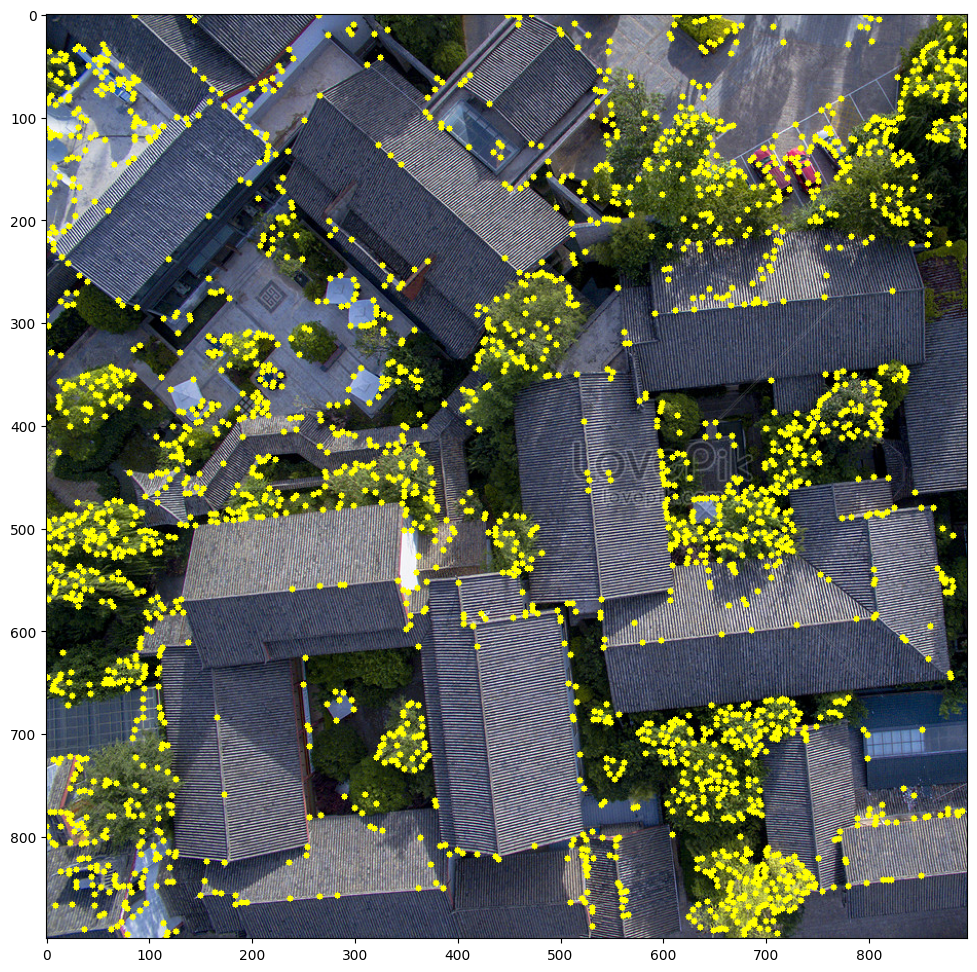

In [19]:
show_img1 = cv2.imread("/Users/harryhoang/Documents/Workspace/HUS/Computer Vision/lab09/images_1.png", cv2.IMREAD_COLOR)
show_img1 = cv2.cvtColor(show_img1, cv2.COLOR_BGR2RGB)
keypoints1 = corner(img1, w=5, kappa=0.01)
ames1_cp = show_img1.copy()
for (x, y) in keypoints1:
    cv2.circle(ames1_cp, (x, y), 3, (255, 255, 0), -1)
plt.figure(1, (18, 12))
plt.imshow(ames1_cp)

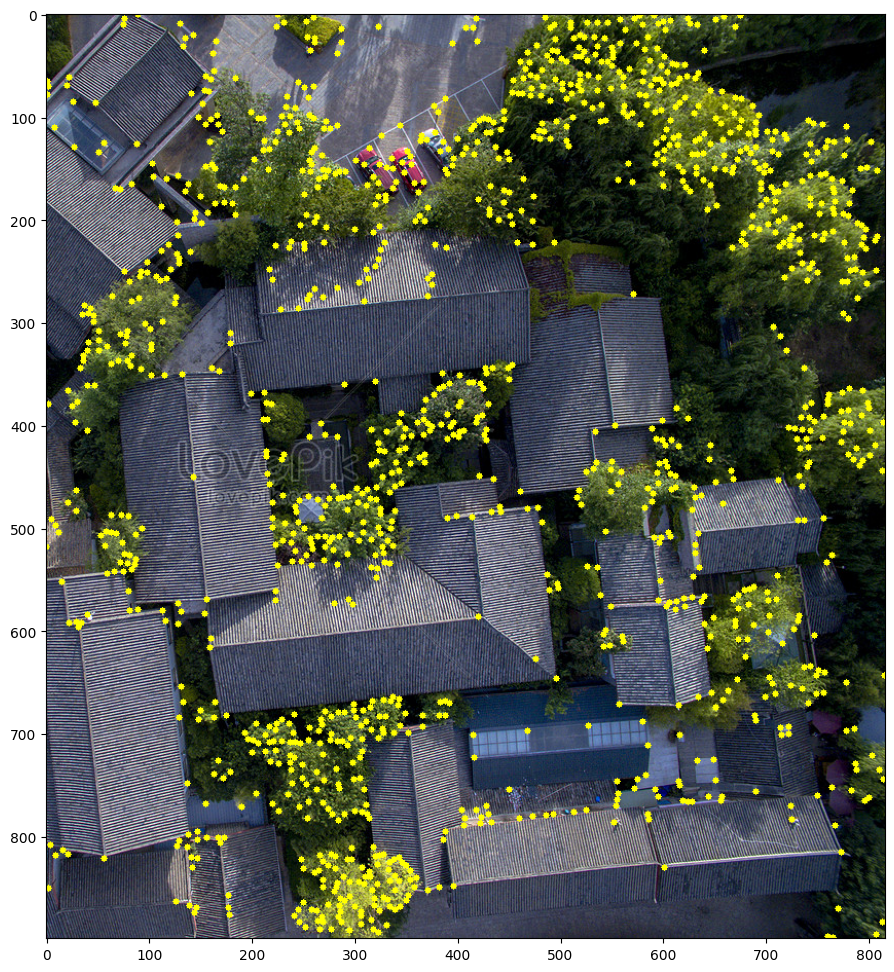

In [20]:
show_img2 = cv2.imread("/Users/harryhoang/Documents/Workspace/HUS/Computer Vision/lab09/images_2.png", cv2.IMREAD_COLOR)
show_img2 = cv2.cvtColor(show_img2, cv2.COLOR_BGR2RGB)
keypoints2 = corner(img2, w=7, kappa=0.05)
ames2_cp = show_img2.copy()
for (x, y) in keypoints2:
    cv2.circle(ames2_cp, (x, y), 3, (255, 255, 0), -1)
plt.figure(1, (18, 12))
plt.imshow(ames2_cp)

Bài 2

In [21]:
def features(image: np.ndarray, keypoints: np.ndarray, patch_size: int = 9) -> np.ndarray:
    assert patch_size % 2 == 1, "patch_size must be odd"
    offset = patch_size // 2
    padded = cv2.copyMakeBorder(image, offset, offset, offset, offset, cv2.BORDER_REFLECT)
    descriptors = []
    for (x, y) in keypoints:
        x0, y0 = x + offset, y + offset
        patch = padded[y0-offset:y0+offset+1, x0-offset:x0+offset+1]
        if patch.shape == (patch_size, patch_size):
            descriptors.append(patch.flatten())
    return np.array(descriptors, dtype=np.float32)

Bài 3

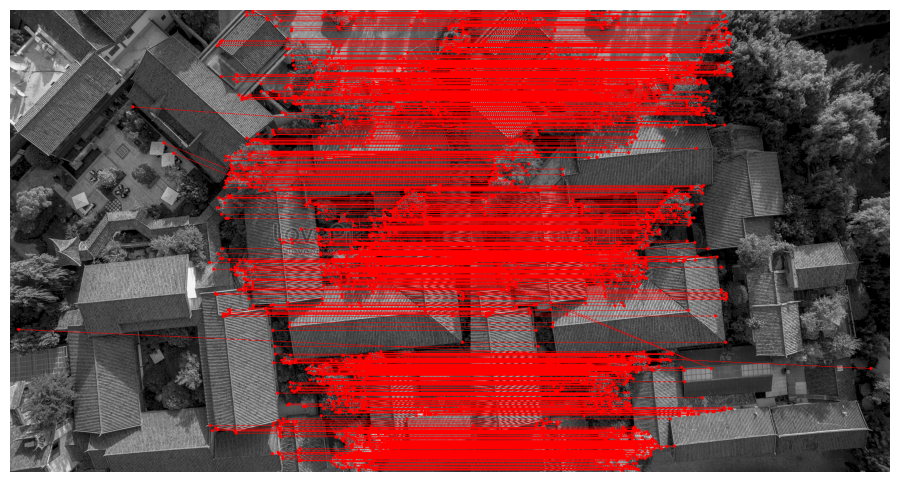

In [30]:
def matching(descriptors1: np.ndarray, descriptors2: np.ndarray, tau: float) -> np.ndarray:
    N1 = descriptors1.shape[0]
    matches = -1 * np.ones(N1, dtype=int)
    for i in range(N1):
        d1 = descriptors1[i]
        ssd = np.sum((descriptors2 - d1) ** 2, axis=1)
        j_best = np.argmin(ssd)
        if ssd[j_best] < tau:
            matches[i] = j_best
    return matches


def draw_matches(img1, img2, kpts1, kpts2, matches):
    if len(img1.shape) == 2:
        img1c = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)
    else:
        img1c = img1.copy()
    if len(img2.shape) == 2:
        img2c = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)
    else:
        img2c = img2.copy()
    h1, w1 = img1c.shape[:2]
    h2, w2 = img2c.shape[:2]
    H = max(h1, h2)
    canvas = np.zeros((H, w1 + w2, 3), dtype=np.uint8)
    canvas[:h1, :w1] = img1c
    canvas[:h2, w1:w1+w2] = img2c
    for i, j in enumerate(matches):
        if j < 0:
            continue

        red_color = (0, 0, 255)
        pt1 = tuple(kpts1[i])
        pt2 = tuple(kpts2[j] + np.array([w1, 0]))
        color = tuple(np.random.randint(0, 255, 3).tolist())
        cv2.circle(canvas, pt1, 3, red_color, -1)
        cv2.circle(canvas, pt2, 3, red_color, -1)
        cv2.line(canvas, pt1, pt2, red_color, 1)
    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

if __name__ == '__main__':
    # Load grayscale images
    img1 = cv2.imread('/Users/harryhoang/Documents/Workspace/HUS/Computer Vision/lab09/images_1.png', cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread('/Users/harryhoang/Documents/Workspace/HUS/Computer Vision/lab09/images_2.png', cv2.IMREAD_GRAYSCALE)

    # Parameters
    w = 5
    kappa = 0.09
    tau = 20000

    # Detect corners using Sobel
    kpts1 = corner(img1, w, kappa)
    kpts2 = corner(img2, w, kappa)

    # Extract descriptors
    desc1 = features(img1, kpts1)
    desc2 = features(img2, kpts2)

    # Match features
    matches = matching(desc1, desc2, tau)

    # Visualize
    draw_matches(img1, img2, kpts1, kpts2, matches)